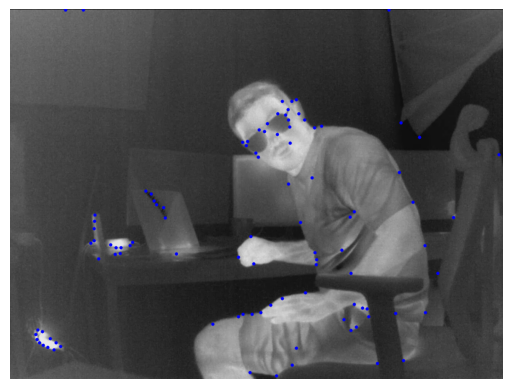

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

save_path = "outputs/feature_detection_and_matching/"
img_path = "images/thermal_image_2.png"
img = cv2.imread(img_path)
if img is None:
    print("Problem finding image")

def _convert_from_bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def _convert_from_bgr_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray_image = _convert_from_bgr_to_gray(img)

# qualityLevel higher → fewer, stronger corners
# minDistance higher → corners more separated
corners = cv2.goodFeaturesToTrack(
    gray_image,
    maxCorners=100,
    qualityLevel=0.01,
    minDistance=10
)

output = img.copy()

if corners is not None:
    corners = corners.astype(int)

    for corner in corners:
        x, y = corner.ravel()
        cv2.circle(output, (x, y), 4, (255, 0, 0), -1)

cv2.imwrite(save_path + "corners.jpg", output)

plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()

Max corners variation
Max corners =  50


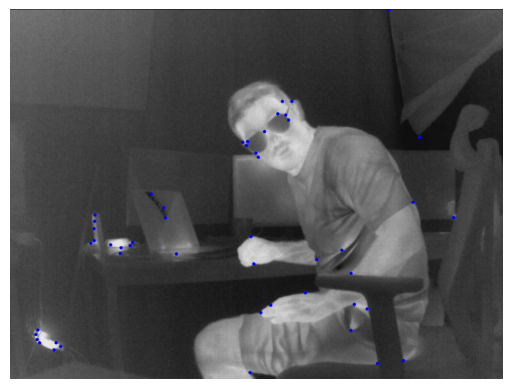

Max corners =  100


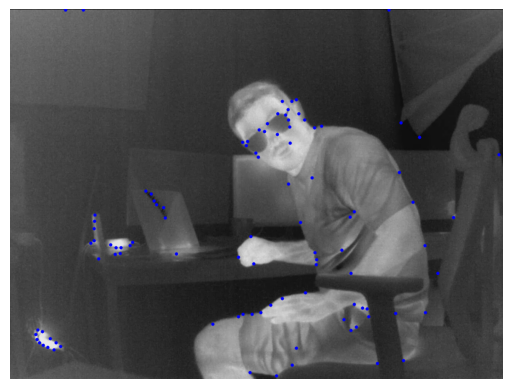

Max corners =  300


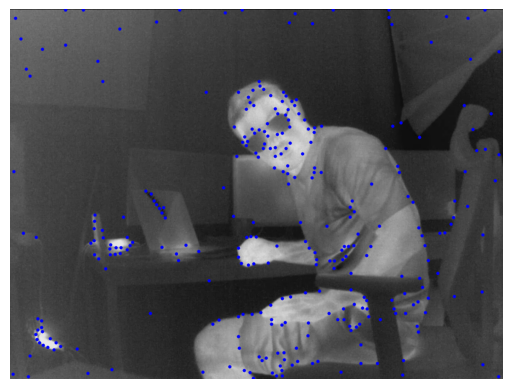

Quality variation
Quality level =  0.01


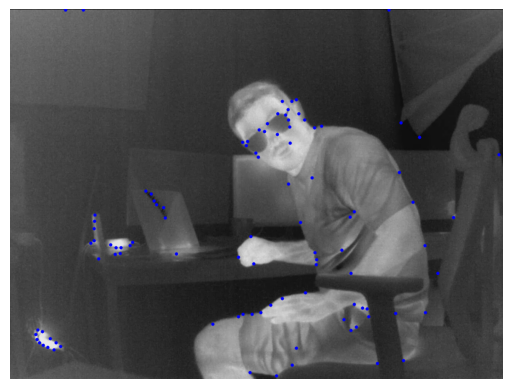

Quality level =  0.05


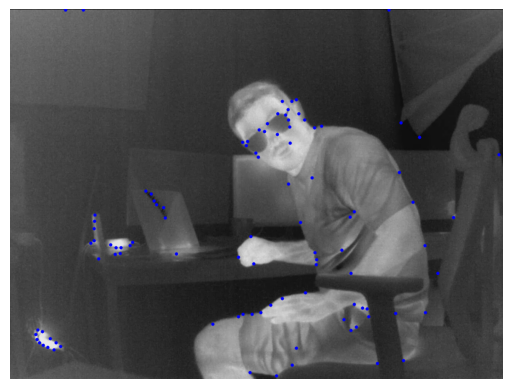

Quality level =  0.1


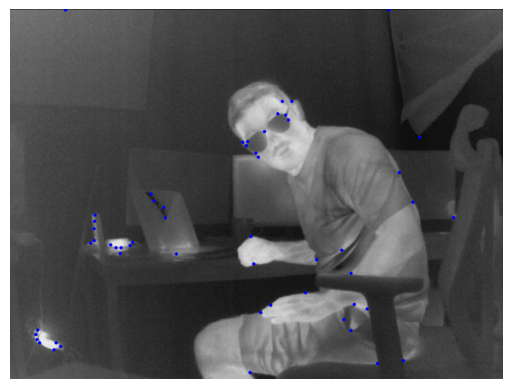

Quality variation
Max distances =  5


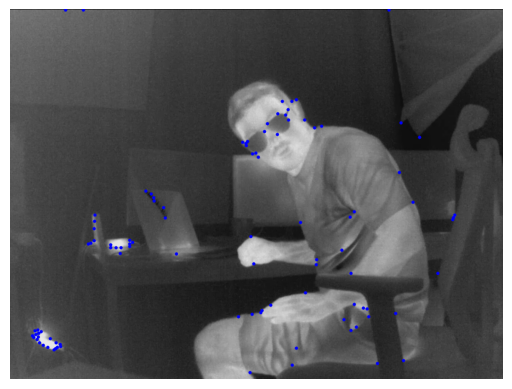

Max distances =  10


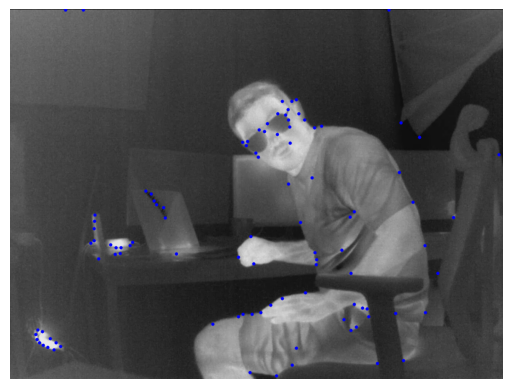

Max distances =  30


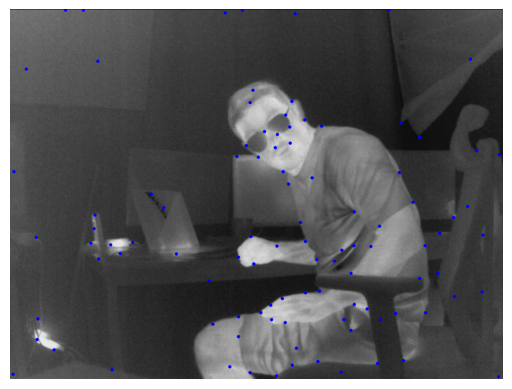

In [8]:
# testing different configurations
maxCorners = (50, 100, 300)

print("Max corners variation")
for value in maxCorners:
    corners_v = cv2.goodFeaturesToTrack(
        gray_image,
        maxCorners=value,
        qualityLevel =0.01,
        minDistance=10
    )

    if corners_v is not None:
        corners_v = corners_v.astype(int)

        output = img.copy()
    
        for corner in corners_v:
            x, y = corner.ravel()
            cv2.circle(output, (x,y), 4, (255,0,0), -1)
    print("Max corners = ", value)
    plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

print("Quality variation")
qualityvalues = (0.01, 0.05, 0.1)
for value in qualityvalues:
    corners_v = cv2.goodFeaturesToTrack(
        gray_image,
        maxCorners=100,
        qualityLevel=value,
        minDistance=10
    )

    if corners_v is not None:
        corners_v = corners_v.astype(int)

        output = img.copy()
    
        for corner in corners_v:
            x, y = corner.ravel()
            cv2.circle(output, (x,y), 4, (255,0,0), -1)
    print("Quality level = ", value)
    plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

print("Quality variation")
distances = (5, 10, 30)
for value in distances:
    corners_v = cv2.goodFeaturesToTrack(
        gray_image,
        maxCorners=100,
        qualityLevel=0.05,
        minDistance=value
    )

    if corners_v is not None:
        corners_v = corners_v.astype(int)

        output = img.copy()
    
        for corner in corners_v:
            x, y = corner.ravel()
            cv2.circle(output, (x,y), 4, (255,0,0), -1)
    print("Max distances = ", value)
    plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

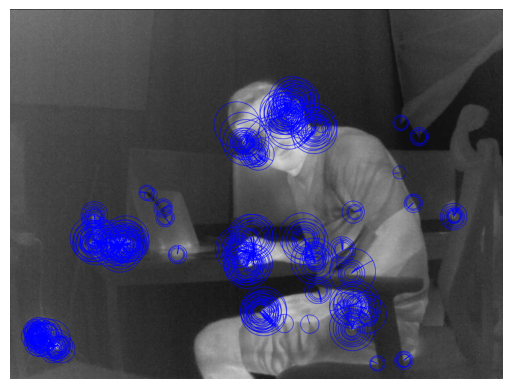

In [12]:
# detect ORB keypoints
orb = cv2.ORB_create(nfeatures=500)
keypoints = orb.detect(gray_image, None)
output = cv2.drawKeypoints(img, keypoints, None, color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

cv2.imwrite(save_path + "orb_keypoints_features_500.jpg", output)

plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [13]:
# orb descriptors
orb = cv2.ORB_create(nfeatures=500)

keypoints, descriptors = orb.detectAndCompute(gray_image, None)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)
print("Descriptor dtype:", descriptors.dtype)

Number of keypoints: 434
Descriptor shape: (434, 32)
Descriptor dtype: uint8


In [15]:
print(descriptors[0])

[ 10 175 186 190 219 224 191 199 191  21  76 163 172 231  34  80 231 123
 171 145  34  75 138 255 255 247 158 171 146  84 165 219]


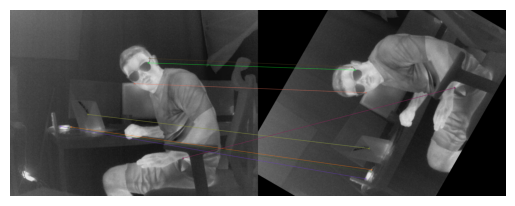

In [26]:
# Match the same image against a rotated version

h, w = img.shape[:2]
center = (w // 2, h // 2)

matrix = cv2.getRotationMatrix2D(center, 60, 1.0)
img_rotated = cv2.warpAffine(img, matrix, (w, h))
gray_rotated = _convert_from_bgr_to_gray(img_rotated)

# create orb
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(gray_image, None)
kp2, des2 = orb.detectAndCompute(gray_rotated, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

matched_img = cv2.drawMatches(
    img,
    kp1,
    img_rotated,
    kp2,
    matches[:10],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2.imwrite(save_path + "/orb_matches_rotate_60_deg.jpg", matched_img)

plt.imshow(_convert_from_bgr_to_rgb(matched_img), vmin=0, vmax=255)
plt.axis("off")
plt.show()

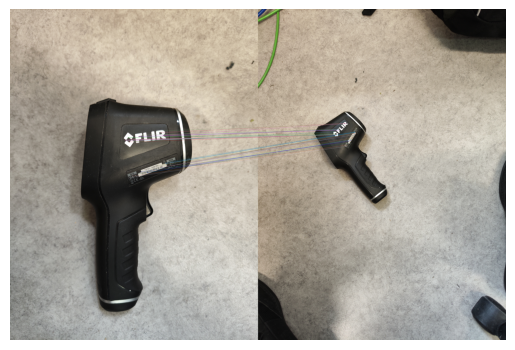

In [29]:

object_img = cv2.imread("images/object.jpg")
scene_img = cv2.imread("images/scene.jpg")

if object_img is None:
    raise FileNotFoundError("object.jpg not found")
if scene_img is None:
    raise FileNotFoundError("scene.jpg not found")

gray_obj = _convert_from_bgr_to_gray(object_img)
gray_scene = _convert_from_bgr_to_gray(scene_img)

orb = cv2.ORB_create(nfeatures=1500)

kp1, des1 = orb.detectAndCompute(gray_obj, None)
kp2, des2 = orb.detectAndCompute(gray_scene, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

matched_img = cv2.drawMatches(
    object_img,
    kp1,
    scene_img,
    kp2,
    matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


cv2.imwrite(save_path + "object_scene_matches.jpg", matched_img)

plt.imshow(_convert_from_bgr_to_rgb(matched_img), vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [30]:
# filtering bad points

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

knn_matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

matched_img = cv2.drawMatches(
    object_img,
    kp1,
    scene_img,
    kp2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2.imwrite(save_path + "object_scene_good_matches.jpg", matched_img)

Good matches: 152


True

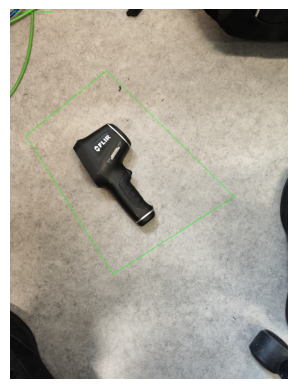

In [32]:
# find object with homography

orb = cv2.ORB_create(nfeatures=2000)

kp1, des1 = orb.detectAndCompute(gray_obj, None)
kp2, des2 = orb.detectAndCompute(gray_scene, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)
knn_matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

output = scene_img.copy()

if len(good_matches) >= 10:
    src_pts = np.float32(
        [kp1[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    dst_pts = np.float32(
        [kp2[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if H is not None:
        h, w = object_img.shape[:2]

        corners = np.float32([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ]).reshape(-1, 1, 2)

        projected_corners = cv2.perspectiveTransform(corners, H)

        output = cv2.polylines(
            output,
            [np.int32(projected_corners)],
            True,
            (0, 255, 0),
            3
        )

        cv2.putText(
            output,
            f"Object found: {len(good_matches)} matches",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )
    else:
        cv2.putText(output, "Homography failed", (30, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
else:
    cv2.putText(output, "Not enough matches", (30, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

cv2.imwrite(save_path + "object_location_homography.jpg", output)

plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()

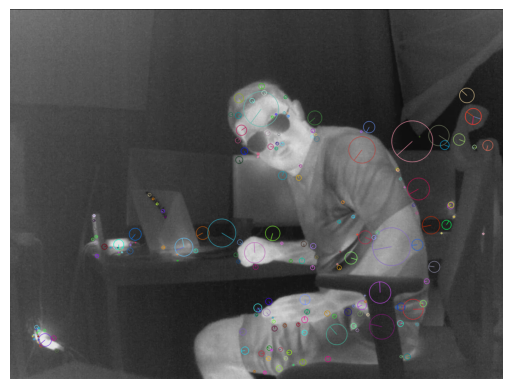

In [3]:
# Comparing ORB and SIFT

sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray_image, None)

output = cv2.drawKeypoints(
    img,
    kp,
    None, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

cv2.imwrite(save_path + "sift_keypoints.jpg", output)

plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()